<a href="https://colab.research.google.com/github/parthasarathipanda2006/Projects/blob/main/Dog_vs_Cat.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import zipfile
import os

zip_file_path = '/content/archive.zip'
extract_dir = '/content/'

if not os.path.exists(extract_dir):
    os.makedirs(extract_dir)

with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(extract_dir)

print(f"Extracted {zip_file_path} to {extract_dir}")
print("Contents of the extracted directory:")
for root, dirs, files in os.walk(extract_dir):
    for file in files:
        print(os.path.join(root, file))

Extracted /content/archive.zip to /content/
Contents of the extracted directory:
/content/archive.zip
/content/.config/gce
/content/.config/hidden_gcloud_config_universe_descriptor_data_cache_configs.db
/content/.config/active_config
/content/.config/default_configs.db
/content/.config/.last_survey_prompt.yaml
/content/.config/.last_opt_in_prompt.yaml
/content/.config/config_sentinel
/content/.config/.last_update_check.json
/content/.config/configurations/config_default
/content/.config/logs/2026.02.06/14.30.32.592228.log
/content/.config/logs/2026.02.06/14.31.28.771044.log
/content/.config/logs/2026.02.06/14.31.44.938153.log
/content/.config/logs/2026.02.06/14.31.35.535753.log
/content/.config/logs/2026.02.06/14.31.19.332851.log
/content/.config/logs/2026.02.06/14.31.45.734270.log
/content/test/cats/cat.4076.jpg
/content/test/cats/cat.4381.jpg
/content/test/cats/cat.4771.jpg
/content/test/cats/cat.4569.jpg
/content/test/cats/cat.4387.jpg
/content/test/cats/cat.4964.jpg
/content/test/c

In [ ]:
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense,Conv2D,MaxPooling2D,Flatten

In [ ]:
from tensorflow import keras
train_ds=keras.utils.image_dataset_from_directory(
    directory='/content/train',
    labels='inferred',
    label_mode='int',
    batch_size=32,
    image_size=(256,256)

)
validation_ds=keras.utils.image_dataset_from_directory(
    directory='/content/test',
    labels='inferred',
    label_mode='int',
    batch_size=32,
    image_size=(256,256)

)


Found 8005 files belonging to 2 classes.
Found 2023 files belonging to 2 classes.


In [ ]:
import tensorflow as tf

def process(image,label):
  image=tf.cast(image/255. ,tf.float32)
  return image,label

train_ds=train_ds.map(process)
validation_ds=validation_ds.map(process)

In [ ]:
model=Sequential()
model.add(Conv2D(32,kernel_size=(3,3),padding='valid',activation='relu',input_shape=(256,256,3)))
model.add(MaxPooling2D(pool_size=(2,2),strides=2,padding='valid'))

model.add(Conv2D(64,kernel_size=(3,3),padding='valid',activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2),strides=2,padding='valid'))

model.add(Conv2D(128,kernel_size=(3,3),padding='valid',activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2),strides=2,padding='valid'))

model.add(Flatten())

model.add(Dense(128,activation='relu'))
model.add(Dense(64,activation='relu'))
model.add(Dense(1,activation='sigmoid'))


In [ ]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 254, 254, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 127, 127, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 125, 125, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 62, 62, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 60, 60, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 30, 30, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 115200)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │    14,745,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,847,297 (56.64 MB)

 Trainable params: 14,847,297 (56.64 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])

In [ ]:
history=model.fit(train_ds,epochs=12,validation_data=validation_ds)

Epoch 1/12
251/251 ━━━━━━━━━━━━━━━━━━━━ 26s 92ms/step - accuracy: 0.5465 - loss: 0.7518 - val_accuracy: 0.6505 - val_loss: 0.6323
Epoch 2/12
251/251 ━━━━━━━━━━━━━━━━━━━━ 20s 79ms/step - accuracy: 0.6569 - loss: 0.6222 - val_accuracy: 0.7049 - val_loss: 0.5995
Epoch 3/12
251/251 ━━━━━━━━━━━━━━━━━━━━ 21s 83ms/step - accuracy: 0.7256 - loss: 0.5317 - val_accuracy: 0.6871 - val_loss: 0.6579
Epoch 4/12
251/251 ━━━━━━━━━━━━━━━━━━━━ 21s 82ms/step - accuracy: 0.8136 - loss: 0.4007 - val_accuracy: 0.7049 - val_loss: 0.8323
Epoch 5/12
251/251 ━━━━━━━━━━━━━━━━━━━━ 20s 78ms/step - accuracy: 0.8916 - loss: 0.2469 - val_accuracy: 0.7009 - val_loss: 1.1048
Epoch 6/12
251/251 ━━━━━━━━━━━━━━━━━━━━ 21s 79ms/step - accuracy: 0.9428 - loss: 0.1376 - val_accuracy: 0.7054 - val_loss: 1.3782
Epoch 7/12
251/251 ━━━━━━━━━━━━━━━━━━━━ 20s 78ms/step - accuracy: 0.9699 - loss: 0.0882 - val_accuracy: 0.7059 - val_loss: 1.4638
Epoch 8/12
251/251 ━━━━━━━━━━━━━━━━━━━━ 21s 78ms/step - accuracy: 0.9802 - loss: 0.0643 - 

251/251 ━━━━━━━━━━━━━━━━━━━━ 12s 45ms/step

Classification Report:
              precision    recall  f1-score   support

           0       0.50      0.52      0.51      4000
           1       0.50      0.48      0.49      4005

    accuracy                           0.50      8005
   macro avg       0.50      0.50      0.50      8005
weighted avg       0.50      0.50      0.50      8005



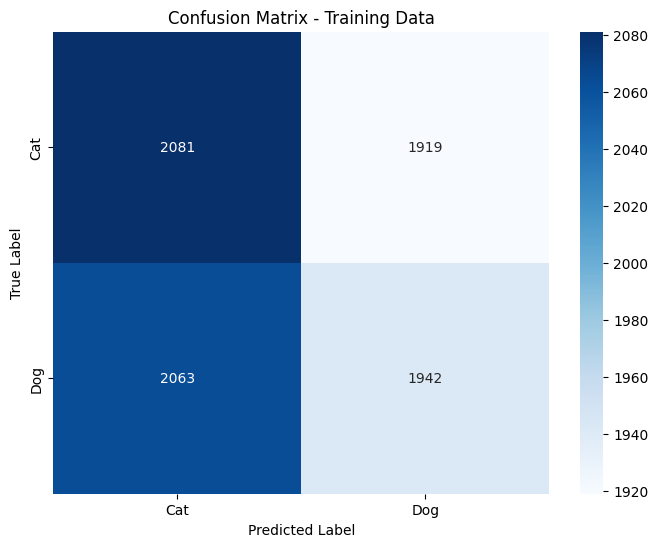

In [ ]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Get predictions on the training set
y_pred = model.predict(train_ds) # Changed from validation_ds to train_ds

# Convert probabilities to binary class labels (0 or 1)
y_pred_classes = (y_pred > 0.5).astype(int)

# Extract true labels from the training_ds
y_true = np.concatenate([y for x, y in train_ds], axis=0)

# Display Classification Report
print("\nClassification Report:")
print(classification_report(y_true, y_pred_classes))

# Display Confusion Matrix
cm = confusion_matrix(y_true, y_pred_classes)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Cat', 'Dog'], yticklabels=['Cat', 'Dog'])
plt.title('Confusion Matrix - Training Data')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

In [ ]:
model=Sequential()
model.add(Conv2D(32,kernel_size=(3,3),padding='valid',activation='relu',input_shape=(256,256,3)))
model.add(MaxPooling2D(pool_size=(2,2),strides=2,padding='valid'))

model.add(Conv2D(64,kernel_size=(3,3),padding='valid',activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2),strides=2,padding='valid'))

model.add(Conv2D(128,kernel_size=(3,3),padding='valid',activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2),strides=2,padding='valid'))

model.add(Flatten())

model.add(Dense(128,activation='relu'))
model.add(Dense(64,activation='relu'))
model.add(Dense(1,activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_9 (Conv2D)               │ (None, 254, 254, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 127, 127, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 125, 125, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 62, 62, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 60, 60, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 30, 30, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 115200)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 128)            │    14,745,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,847,297 (56.64 MB)

 Trainable params: 14,847,297 (56.64 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])

In [ ]:
history=model.fit(train_ds,epochs=12,validation_data=validation_ds)

Epoch 1/12
251/251 ━━━━━━━━━━━━━━━━━━━━ 26s 91ms/step - accuracy: 0.5439 - loss: 0.7493 - val_accuracy: 0.6915 - val_loss: 0.5951
Epoch 2/12
251/251 ━━━━━━━━━━━━━━━━━━━━ 37s 80ms/step - accuracy: 0.6793 - loss: 0.5870 - val_accuracy: 0.7242 - val_loss: 0.5395
Epoch 3/12
251/251 ━━━━━━━━━━━━━━━━━━━━ 20s 79ms/step - accuracy: 0.7662 - loss: 0.4881 - val_accuracy: 0.7360 - val_loss: 0.5298
Epoch 4/12
251/251 ━━━━━━━━━━━━━━━━━━━━ 20s 79ms/step - accuracy: 0.8079 - loss: 0.3999 - val_accuracy: 0.7499 - val_loss: 0.6707
Epoch 5/12
251/251 ━━━━━━━━━━━━━━━━━━━━ 20s 78ms/step - accuracy: 0.8822 - loss: 0.2850 - val_accuracy: 0.7449 - val_loss: 0.6885
Epoch 6/12
251/251 ━━━━━━━━━━━━━━━━━━━━ 20s 79ms/step - accuracy: 0.9189 - loss: 0.1953 - val_accuracy: 0.7415 - val_loss: 0.7837
Epoch 7/12
251/251 ━━━━━━━━━━━━━━━━━━━━ 20s 81ms/step - accuracy: 0.9549 - loss: 0.1134 - val_accuracy: 0.7301 - val_loss: 1.0311
Epoch 8/12
251/251 ━━━━━━━━━━━━━━━━━━━━ 20s 78ms/step - accuracy: 0.9753 - loss: 0.0645 - 

64/64 ━━━━━━━━━━━━━━━━━━━━ 3s 45ms/step

Classification Report:
              precision    recall  f1-score   support

           0       0.49      0.54      0.51      1011
           1       0.48      0.43      0.45      1012

    accuracy                           0.49      2023
   macro avg       0.49      0.49      0.48      2023
weighted avg       0.49      0.49      0.48      2023



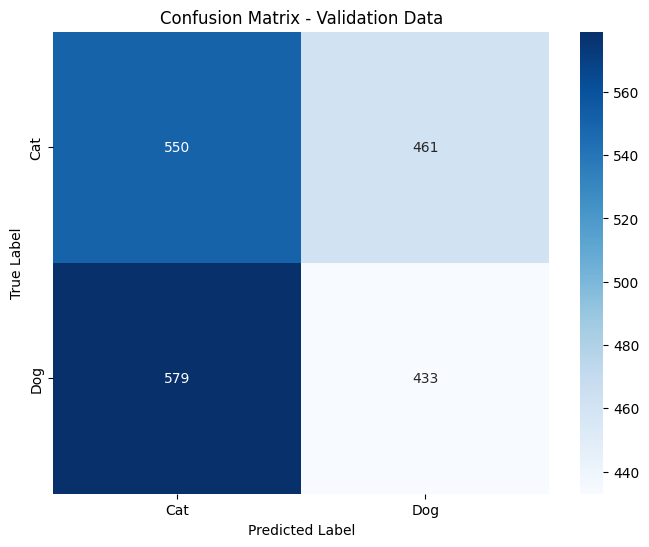

In [ ]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Get predictions on the validation set
y_pred = model.predict(validation_ds)

# Convert probabilities to binary class labels (0 or 1)
y_pred_classes = (y_pred > 0.5).astype(int)

# Extract true labels from the validation_ds
y_true = np.concatenate([y for x, y in validation_ds], axis=0)

# Display Classification Report
print("\nClassification Report:")
print(classification_report(y_true, y_pred_classes))

# Display Confusion Matrix
cm = confusion_matrix(y_true, y_pred_classes)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Cat', 'Dog'], yticklabels=['Cat', 'Dog'])
plt.title('Confusion Matrix - Validation Data')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()